<a href="https://colab.research.google.com/github/fgasperij/FBGEMM/blob/main/sprint1_part4_lab1_llm_as_a_judge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM-as-a-Judge: Evaluating a Career Advice Chatbot

In this notebook, you will build a **complete evaluation pipeline** for a conversational chatbot using the **LLM-as-a-judge** paradigm. You will:

1. Build a career advice chatbot with multiple prompt variants
2. Design a test dataset covering diverse scenarios
3. Implement automated evaluation using G-Eval dimensions
4. Analyze results to determine which prompt strategy works best

---

### Academic Foundation

Our approach draws on three key papers:

- **G-Eval** ([Liu et al., 2023](https://arxiv.org/abs/2303.16634)) — LLM-based evaluation using 4 dimensions (Coherence, Relevance, Fluency, Consistency) on a 1–5 Likert scale. Achieves the highest correlation with human judgments among automated metrics.
- **MT-Bench** ([Zheng et al., 2023](https://arxiv.org/abs/2306.05685)) — Established the LLM-as-a-judge paradigm, demonstrating >80% agreement with human evaluators.
- **Prometheus** ([Kim et al., 2024](https://arxiv.org/abs/2405.01535)) — Showed that fine-grained rubrics with reference materials significantly improve evaluation quality.

We combine these ideas: G-Eval's dimensions, MT-Bench's judge paradigm, and Prometheus-style reference-guided evaluation with `key_aspects` for each test case.

## Section 1: Setup

### Install Dependencies

We use only core libraries — no external evaluation frameworks. Building from scratch helps you understand the internals.

In [ ]:
%pip install openai pandas matplotlib python-dotenv -q

### (Optional) Saving API keys securely in Secrets tab

In production systems, saving API keys plainly in the code is not recommended.
You can instead save API keys in the Secrets tab in the Google Colab.

Just make sure to name these keys properly and read them in the Python cell:
* OPENAI_API_KEY
* GEMINI_API_KEY
* ANTHROPIC_API_KEY

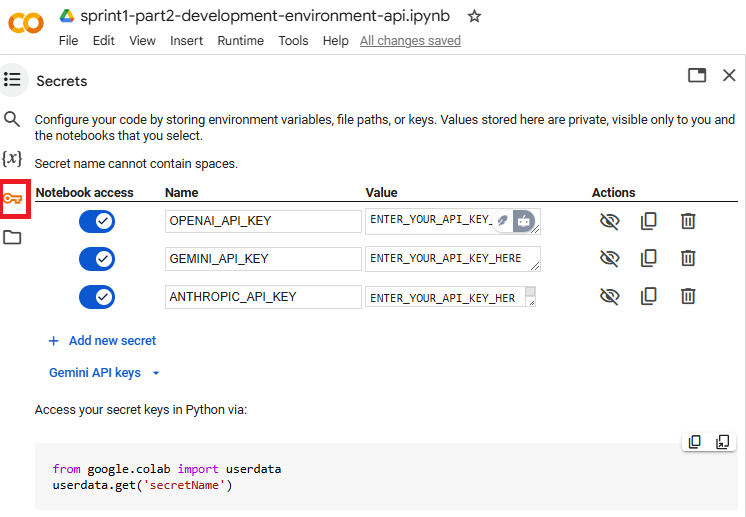

In [ ]:
from google.colab import userdata
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')

# Alternatively, comment out the above and define the API keys via your own method:
# OPENAI_API_KEY =

In [ ]:
import os
from openai import OpenAI

client = OpenAI(api_key=OPENAI_API_KEY)

# Verify the connection
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Say 'connection OK' in exactly two words."}],
)
print("API check:", response.choices[0].message.content)

API check: Connection OK.


## Section 2: Career Advice Chatbot

We'll create a simple career advice chatbot and test **three prompt strategies**: zero-shot, few-shot, and a third "custom" prompt that is effectively zero-shot but with more detailed instructions.

### Helper Function

In [ ]:
MODEL = "gpt-4o-mini"


def get_career_advice(question: str, system_prompt: str) -> str:
    """Send a career question to the chatbot and return the response."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": question},
        ],
    )
    return response.choices[0].message.content

### Prompt Variants

We define two prompt strategies to compare, plus an empty slot for your own:

- **A (Zero-shot):** Just a role and task description — no examples, no structure.
- **B (Few-shot):** Includes 2–3 example Q&A pairs demonstrating the ideal format and depth.
- **C (Custom):** Zero-shot, but with more detailed instructions

In [ ]:
PROMPTS = {}

# --- Variant A: Zero-shot ---
PROMPTS["A_zero_shot"] = "You are a career advisor. Give a brief answer to the user's question in 2-3 sentences. Be concise."

# --- Variant B: Few-shot ---
PROMPTS["B_few_shot"] = """You are an experienced career advisor who provides thoughtful, actionable career guidance. For each question, provide a structured response that includes:
1. A brief assessment of the situation
2. Specific, actionable recommendations (at least 3)
3. Potential risks or considerations to keep in mind

Here are examples of how to respond:

---
USER: I'm a teacher considering a switch to corporate training. How should I approach this?

ADVISOR:
**Situation Assessment:** Your teaching background gives you strong foundations in curriculum design, presentation skills, and learner engagement — all highly valued in corporate training. The transition is very achievable with targeted positioning.

**Recommendations:**
1. Reframe your resume to highlight transferable skills: curriculum design becomes "learning program development," classroom management becomes "facilitating groups of 20-40 professionals."
2. Get a quick certification in corporate L&D — something like ATD's Associate Professional in Talent Development (APTD) signals industry awareness.
3. Start networking on LinkedIn with L&D professionals. Comment on posts, share insights about adult learning — your expertise here is genuine and valuable.
4. Consider a stepping stone: many companies hire teachers as onboarding specialists or training coordinators, which can lead to senior training roles within 1-2 years.

**Key Considerations:**
- Corporate training roles often pay 20-40% more than teaching but may require travel.
- You may miss the long-term student relationships — corporate training is typically shorter engagements.
- Some industries (tech, healthcare) have much higher demand for trainers than others.

---
USER: How do I deal with imposter syndrome in a new senior role?

ADVISOR:
**Situation Assessment:** Imposter syndrome is extremely common in role transitions — studies suggest 70% of people experience it. It often intensifies when moving into leadership because visibility increases and the feedback loop is less immediate than in individual contributor roles.

**Recommendations:**
1. Keep a "wins file" — a simple document where you record accomplishments, positive feedback, and problems you've solved. Review it weekly during your first 90 days.
2. Schedule regular 1-on-1s with your manager with an explicit agenda item: "What's going well and what should I adjust?" This replaces the anxiety of guessing with concrete data.
3. Find a peer mentor at the same level (inside or outside the company) who you can be honest with. Normalizing the experience is one of the most effective strategies.

**Key Considerations:**
- Avoid overcompensating by overworking — this leads to burnout, not confidence.
- Give yourself a 90-day grace period. No one expects mastery on day one.
- If it persists beyond 6 months and affects your well-being, consider working with a coach who specializes in leadership transitions.

---

Now respond to the user's question following this same format and depth."""

# --- Variant C: Custom ---
# Feel free to experiment - try a different approach: persona-based, structured output, chain-of-thought, etc.
PROMPTS["C_custom"] = """You are a senior career strategist with 20 years of experience in HR, executive coaching, and talent development across Fortune 500 companies and startups. You combine empathy with directness.

For every question:
- First, identify what the person is REALLY asking (the underlying concern, not just the surface question)
- Provide advice that is specific enough to act on THIS WEEK
- Include one unconventional or non-obvious insight
- If the question is off-topic (not career-related), politely redirect to career topics

Keep your response concise but substantive (200-400 words). Avoid generic platitudes like 'follow your passion' or 'believe in yourself.'"""

### Smoke Test

Let's compare all variants on a single question to see how they differ.

In [ ]:
test_question = "I'm a software developer thinking about moving into data science. What should I do?"

for name, prompt in PROMPTS.items():
    print(f"\n{'='*60}")
    print(f"Variant: {name}")
    print(f"{'='*60}")
    response = get_career_advice(test_question, prompt)
    print(response[:500], "..." if len(response) > 500 else "")
    print()


Variant: A_zero_shot
Start by building a strong foundation in statistics, data manipulation, and machine learning concepts. Familiarize yourself with data science libraries in Python or R, such as pandas, NumPy, and scikit-learn. Consider taking online courses, attending workshops, or working on personal projects to enhance your skills and create a portfolio. 


Variant: B_few_shot
**Situation Assessment:** As a software developer, you already possess strong analytical skills, programming proficiency, and problem-solving abilities. These are critical in data science. However, you'll need to bridge the gap in your knowledge of statistics, machine learning, and data manipulation techniques to successfully transition.

**Recommendations:**
1. **Enhance Your Skills through Online Courses:** Start with platforms like Coursera or edX to take courses in data science and machine l ...


Variant: C_custom
What you’re really asking is how to transition your career effectively while ensuring tha

## Section 3: Test Dataset

A good evaluation dataset needs **diversity** across:
- **Categories** — different types of career questions
- **Difficulty levels** — from straightforward to complex/nuanced
- **Edge cases** — off-topic or ambiguous inputs

Each test case includes `key_aspects` — a lightweight reference describing what a good answer should cover. This follows the **Prometheus** approach of reference-guided evaluation.

In [ ]:
TEST_CASES = [
    {
        "id": 1,
        "question": "I'm a software developer thinking about switching to data science. What steps should I take?",
        "category": "career_transition",
        "difficulty": "easy",
        "key_aspects": "Should mention: transferable skills (programming, analytical thinking), specific learning path (statistics, ML, Python data stack), portfolio building, potential entry points (internal transfer, hybrid roles), realistic timeline.",
    },
    {
        "id": 2,
        "question": "My manager said there's no budget for raises this year, but I know I'm underpaid by at least 20%. How do I negotiate?",
        "category": "salary_negotiation",
        "difficulty": "medium",
        "key_aspects": "Should address: market data and salary benchmarks, timing strategies, alternative compensation (equity, title, PTO, remote work), framing the ask around value delivered, when to consider leaving, avoiding ultimatums.",
    },
    {
        "id": 3,
        "question": "I've been an engineering manager for 5 years but want to go back to being an individual contributor. How do I do this without it looking like a step backward?",
        "category": "career_transition",
        "difficulty": "hard",
        "key_aspects": "Should address: reframing as a strategic choice (not failure), narrative for interviews, common in tech (staff/principal engineer paths), targeting companies that value IC track, potential title and comp implications, leveraging management experience as a differentiator.",
    },
    {
        "id": 4,
        "question": "What technical skills should I learn to future-proof my career in the next 5 years?",
        "category": "skill_development",
        "difficulty": "medium",
        "key_aspects": "Should mention: AI/ML literacy, cloud platforms, data skills, avoiding hype-driven learning, focusing on fundamentals (problem-solving, system design), balancing depth vs breadth, continuous learning habits.",
    },
    {
        "id": 5,
        "question": "My boss regularly takes credit for my work in front of leadership. How should I handle this?",
        "category": "workplace_conflict",
        "difficulty": "medium",
        "key_aspects": "Should address: documentation strategies, building visibility independently (skip-level meetings, cross-team work), direct conversation approach, escalation path if it continues, protecting yourself without being confrontational, when to involve HR.",
    },
    {
        "id": 6,
        "question": "I have two offers: a well-funded startup (higher equity, exciting product) and a big tech company (stable, higher base salary). How do I decide?",
        "category": "job_decision",
        "difficulty": "hard",
        "key_aspects": "Should address: risk tolerance assessment, total compensation analysis (equity valuation realism), career growth trajectory, learning opportunities, work-life balance differences, personal financial situation, stage of career considerations.",
    },
    {
        "id": 7,
        "question": "I'm an introvert and networking feels exhausting and fake. How can I build professional connections authentically?",
        "category": "networking",
        "difficulty": "easy",
        "key_aspects": "Should address: reframing networking as relationship-building, quality over quantity, leveraging written communication (LinkedIn, blogs), small group settings, offering value first, energy management strategies, online communities.",
    },
    {
        "id": 8,
        "question": "I'm 45 and worried about age discrimination in the tech industry. How do I stay competitive?",
        "category": "career_transition",
        "difficulty": "hard",
        "key_aspects": "Should address: leveraging experience as an asset (mentorship, architecture, stakeholder management), staying technically current without chasing every trend, targeting companies with mature cultures, legal protections, avoiding ageist red flags on resume, the real value of wisdom and stability.",
    },
    {
        "id": 9,
        "question": "Should I get an MBA or learn to code? I'm a marketing manager wanting to move into product management.",
        "category": "education",
        "difficulty": "medium",
        "key_aspects": "Should address: ROI comparison (MBA cost vs free/cheap coding resources), what PM roles actually require, hybrid path possibility, network value of MBA vs practical skills, company-specific requirements, timeline and opportunity cost.",
    },
    {
        "id": 10,
        "question": "I want to start freelancing but I'm scared of the instability. How do I make the transition safely?",
        "category": "entrepreneurship",
        "difficulty": "medium",
        "key_aspects": "Should address: side-hustle-first approach, financial runway (6+ months expenses), building client pipeline before quitting, pricing strategy, legal/tax considerations, maintaining health insurance, portfolio and online presence.",
    },
    {
        "id": 11,
        "question": "Tell me a joke",
        "category": "off_topic",
        "difficulty": "edge_case",
        "key_aspects": "Should recognize this is off-topic for career advice, politely redirect to career-related questions. Should NOT just tell a joke without any career context. A witty career-related joke is acceptable if followed by an offer to help with career questions.",
    },
    {
        "id": 12,
        "question": "I just feel stuck. I don't even know what I want to do with my career anymore. Everything feels pointless.",
        "category": "career_exploration",
        "difficulty": "hard",
        "key_aspects": "Should address: normalizing the feeling, distinguishing career dissatisfaction from burnout or depression, self-assessment exercises, exploring through low-commitment experiments (volunteering, side projects), professional help (career coach, therapist), avoiding drastic decisions while in this state.",
    },
]

print(f"Test dataset: {len(TEST_CASES)} cases")
print(f"Categories: {sorted(set(tc['category'] for tc in TEST_CASES))}")
print(f"Difficulties: {sorted(set(tc['difficulty'] for tc in TEST_CASES))}")

Test dataset: 12 cases
Categories: ['career_exploration', 'career_transition', 'education', 'entrepreneurship', 'job_decision', 'networking', 'off_topic', 'salary_negotiation', 'skill_development', 'workplace_conflict']
Difficulties: ['easy', 'edge_case', 'hard', 'medium']


## Section 4: LLM-as-a-Judge

We evaluate each chatbot response using four **G-Eval dimensions**, adapted for conversational career advice:

| Dimension | What it measures |
|-----------|------------------|
| **Coherence** | Is the response logically structured and well-organized? |
| **Relevance** | Does it address the specific question and cover key aspects? |
| **Fluency** | Is the language natural, professional, and clear? |
| **Consistency** | Is the advice internally consistent (no contradictions)? |

Each dimension is scored 1–5 on a Likert scale with detailed rubrics.

> **Note:** We use `gpt-5-mini` as our judge. Since it's a reasoning model, we don't need explicit chain-of-thought instructions — the model handles this natively.

In [ ]:
JUDGE_PROMPT_TEMPLATE = """You are an expert evaluator assessing the quality of a career advice chatbot response.

## Task
Evaluate the following response on four dimensions, each scored 1-5.

## Question Asked
{question}

## Reference: Key Aspects a Good Answer Should Cover
{key_aspects}

## Response to Evaluate
{response}

## Scoring Rubric

### Coherence (logical structure and organization)
1 - No structure, random thoughts jumbled together
2 - Weak structure, some ideas connected but mostly disorganized
3 - Adequate structure, main points identifiable but flow could be improved
4 - Well-structured, logical progression with clear sections
5 - Excellent structure, perfectly organized with smooth transitions between ideas

### Relevance (addresses the question and covers key aspects)
1 - Completely off-topic or generic advice unrelated to the question
2 - Partially relevant but misses the main concern; covers few key aspects
3 - Addresses the question but misses several important key aspects
4 - Directly addresses the question and covers most key aspects
5 - Thoroughly addresses the question, covers all key aspects with specific details

### Fluency (natural, professional, clear language)
1 - Difficult to read, major grammar/clarity issues
2 - Understandable but awkward phrasing or unclear passages
3 - Clear and readable but somewhat generic or flat in tone
4 - Professional and engaging, clear language throughout
5 - Exceptionally well-written, natural conversational tone, engaging and professional

### Consistency (no contradictions, internally aligned advice)
1 - Major contradictions, advice conflicts with itself
2 - Some inconsistencies that could confuse the reader
3 - Mostly consistent with minor tensions between points
4 - Consistent throughout, advice aligns well
5 - Perfectly consistent, all points reinforce each other

## Output Format
First provide your reasoning, then score each dimension.
Use EXACTLY this format:

REASONING: <your overall assessment>
Coherence: <score> | <one-sentence justification>
Relevance: <score> | <one-sentence justification>
Fluency: <score> | <one-sentence justification>
Consistency: <score> | <one-sentence justification>"""

print("Judge prompt template ready.")
print(f"Template length: {len(JUDGE_PROMPT_TEMPLATE)} characters")

Judge prompt template ready.
Template length: 2170 characters


In [ ]:
def evaluate_response(question: str, response: str, key_aspects: str) -> str:
    """Use the LLM judge to evaluate a chatbot response."""
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        question=question,
        key_aspects=key_aspects,
        response=response,
    )
    result = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
    )
    return result.choices[0].message.content


def parse_judge_output(judge_output: str) -> dict:
    """Parse the judge's structured output into a dictionary of scores and justifications.

    Returns a dict like:
    {
        "Coherence": {"score": 4, "justification": "..."},
        "Relevance": {"score": 5, "justification": "..."},
        ...
        "reasoning": "...",
        "parse_error": False
    }
    """
    dimensions = ["Coherence", "Relevance", "Fluency", "Consistency"]
    result = {"reasoning": "", "parse_error": False}

    # Extract reasoning
    if "REASONING:" in judge_output:
        reasoning_start = judge_output.index("REASONING:") + len("REASONING:")
        # Find where the first dimension starts
        first_dim_pos = len(judge_output)
        for dim in dimensions:
            pos = judge_output.find(f"{dim}:")
            if pos != -1 and pos < first_dim_pos and pos > reasoning_start:
                first_dim_pos = pos
        result["reasoning"] = judge_output[reasoning_start:first_dim_pos].strip()

    # Extract each dimension score
    for dim in dimensions:
        try:
            # Find the line with this dimension
            lines = judge_output.split("\n")
            dim_line = None
            for line in lines:
                stripped = line.strip()
                if stripped.startswith(f"{dim}:") or stripped.startswith(f"**{dim}"):
                    dim_line = stripped
                    break

            if dim_line is None:
                raise ValueError(f"Dimension {dim} not found")

            # Parse "Dimension: score | justification"
            after_colon = dim_line.split(":", 1)[1].strip()
            # Remove any markdown bold markers
            after_colon = after_colon.replace("**", "")

            if "|" in after_colon:
                score_part, justification = after_colon.split("|", 1)
            else:
                score_part = after_colon.split()[0]
                justification = after_colon

            # Extract the numeric score
            score_str = "".join(c for c in score_part if c.isdigit())
            score = int(score_str)
            score = max(1, min(5, score))  # clamp to 1-5

            result[dim] = {"score": score, "justification": justification.strip()}
        except (ValueError, IndexError) as e:
            result[dim] = {"score": 3, "justification": f"PARSE ERROR: {e}"}
            result["parse_error"] = True

    return result


print("Evaluation functions defined.")

Evaluation functions defined.


### Quick Test: Evaluate One Response

Let's verify the judge works on a single test case before running the full pipeline.

In [ ]:
# Quick test on a single case
test_case = TEST_CASES[0]
test_response = get_career_advice(test_case["question"], PROMPTS["A_zero_shot"])

print("Question:", test_case["question"])
print("\nResponse (first 300 chars):")
print(test_response[:300], "...")

judge_output = evaluate_response(
    test_case["question"], test_response, test_case["key_aspects"]
)
print("\n--- Judge Output ---")
print(judge_output)

parsed = parse_judge_output(judge_output)
print("\n--- Parsed Scores ---")
for dim in ["Coherence", "Relevance", "Fluency", "Consistency"]:
    print(f"  {dim}: {parsed[dim]['score']} — {parsed[dim]['justification']}")
print(f"  Parse error: {parsed['parse_error']}")

Question: I'm a software developer thinking about switching to data science. What steps should I take?

Response (first 300 chars):
To transition from software development to data science, start by building your statistical and analytical skills through online courses or a formal degree in data science or a related field. Gain proficiency in data manipulation libraries (like Pandas) and machine learning frameworks (like scikit-l ...

--- Judge Output ---
REASONING: The response provides a structured and relevant approach for a software developer transitioning to data science, covering some key aspects such as skill development and portfolio building but missing out on explicit mentions of transferable skills and a realistic timeline.

Coherence: 4 | The response is generally well-structured with a logical flow of ideas outlining steps to take for the transition.
Relevance: 4 | It addresses the main question and covers most key aspects, though it could mention transferable skills more e

## Section 5: Full Evaluation Pipeline

Now we run every prompt variant against every test case, then evaluate each response with our judge.

This produces **variant_count × 12 chatbot calls + variant_count × 12 judge calls**.

In [ ]:
import pandas as pd

results = []
total = len(PROMPTS) * len(TEST_CASES)
current = 0

for variant_name, system_prompt in PROMPTS.items():
    for tc in TEST_CASES:
        current += 1
        print(f"[{current}/{total}] {variant_name} — Q{tc['id']} ({tc['category']})")

        # Get chatbot response
        response = get_career_advice(tc["question"], system_prompt)

        # Judge the response
        judge_output = evaluate_response(tc["question"], response, tc["key_aspects"])
        parsed = parse_judge_output(judge_output)

        # Store everything
        row = {
            "variant": variant_name,
            "question_id": tc["id"],
            "category": tc["category"],
            "difficulty": tc["difficulty"],
            "question": tc["question"],
            "response": response,
            "judge_output": judge_output,
            "reasoning": parsed["reasoning"],
            "parse_error": parsed["parse_error"],
        }
        for dim in ["Coherence", "Relevance", "Fluency", "Consistency"]:
            row[f"{dim}_score"] = parsed[dim]["score"]
            row[f"{dim}_justification"] = parsed[dim]["justification"]

        results.append(row)

df = pd.DataFrame(results)
print(f"\nDone! {len(df)} evaluations completed.")
print(f"Parse errors: {df['parse_error'].sum()}")

[1/36] A_zero_shot — Q1 (career_transition)
[2/36] A_zero_shot — Q2 (salary_negotiation)
[3/36] A_zero_shot — Q3 (career_transition)
[4/36] A_zero_shot — Q4 (skill_development)
[5/36] A_zero_shot — Q5 (workplace_conflict)
[6/36] A_zero_shot — Q6 (job_decision)
[7/36] A_zero_shot — Q7 (networking)
[8/36] A_zero_shot — Q8 (career_transition)
[9/36] A_zero_shot — Q9 (education)
[10/36] A_zero_shot — Q10 (entrepreneurship)
[11/36] A_zero_shot — Q11 (off_topic)
[12/36] A_zero_shot — Q12 (career_exploration)
[13/36] B_few_shot — Q1 (career_transition)
[14/36] B_few_shot — Q2 (salary_negotiation)
[15/36] B_few_shot — Q3 (career_transition)
[16/36] B_few_shot — Q4 (skill_development)
[17/36] B_few_shot — Q5 (workplace_conflict)
[18/36] B_few_shot — Q6 (job_decision)
[19/36] B_few_shot — Q7 (networking)
[20/36] B_few_shot — Q8 (career_transition)
[21/36] B_few_shot — Q9 (education)
[22/36] B_few_shot — Q10 (entrepreneurship)
[23/36] B_few_shot — Q11 (off_topic)
[24/36] B_few_shot — Q12 (career_

In [ ]:
# Quick sanity check
print(df[["variant", "question_id", "Coherence_score", "Relevance_score", "Fluency_score", "Consistency_score"]].to_string(index=False))

    variant  question_id  Coherence_score  Relevance_score  Fluency_score  Consistency_score
A_zero_shot            1                4                3              4                  4
A_zero_shot            2                4                4              4                  4
A_zero_shot            3                3                3              4                  4
A_zero_shot            4                4                3              4                  4
A_zero_shot            5                4                3              4                  4
A_zero_shot            6                4                3              4                  4
A_zero_shot            7                4                3              4                  4
A_zero_shot            8                3                3              4                  4
A_zero_shot            9                3                2              4                  4
A_zero_shot           10                4                3            

## Section 6: Results Analysis

### Aggregate Comparison Table

Mean scores per variant across all dimensions.

In [ ]:
score_cols = ["Coherence_score", "Relevance_score", "Fluency_score", "Consistency_score"]

# Mean scores per variant
summary = df.groupby("variant")[score_cols].mean().round(2)
summary["Overall"] = summary[score_cols].mean(axis=1).round(2)
summary.columns = [c.replace("_score", "") for c in summary.columns]
print(summary.to_string())
print()

# Highlight the winner
best = summary["Overall"].idxmax()
print(f"Best overall variant: {best} (Overall = {summary.loc[best, 'Overall']})")

             Coherence  Relevance  Fluency  Consistency  Overall
variant                                                         
A_zero_shot       3.67       3.00     4.00         4.00     3.67
B_few_shot        4.08       4.50     4.08         4.75     4.35
C_custom          4.17       4.58     4.25         4.92     4.48

Best overall variant: C_custom (Overall = 4.48)


### Visualization: Overall and Per-Dimension Scores

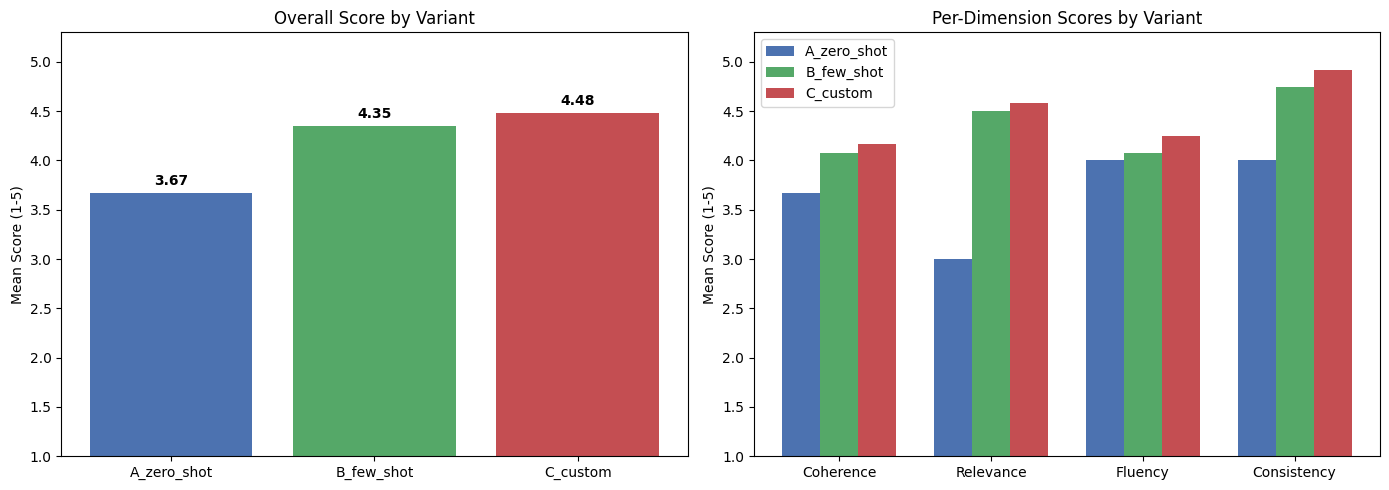

In [ ]:
import matplotlib.pyplot as plt

dimensions = ["Coherence", "Relevance", "Fluency", "Consistency"]
variants = list(PROMPTS.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Overall scores ---
overall_scores = [summary.loc[v, "Overall"] for v in variants]
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = axes[0].bar(variants, overall_scores, color=colors[:len(variants)])
axes[0].set_ylabel("Mean Score (1-5)")
axes[0].set_title("Overall Score by Variant")
axes[0].set_ylim(1, 5.3)
for bar, score in zip(bars, overall_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{score:.2f}", ha="center", va="bottom", fontweight="bold")

# --- Plot 2: Per-dimension grouped bar chart ---
x = range(len(dimensions))
width = 0.25
for i, variant in enumerate(variants):
    scores = [summary.loc[variant, dim] for dim in dimensions]
    offset = (i - len(variants) / 2 + 0.5) * width
    axes[1].bar([xi + offset for xi in x], scores, width,
                label=variant, color=colors[i % len(colors)])

axes[1].set_xticks(x)
axes[1].set_xticklabels(dimensions)
axes[1].set_ylabel("Mean Score (1-5)")
axes[1].set_title("Per-Dimension Scores by Variant")
axes[1].set_ylim(1, 5.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Difficulty Breakdown

How does each variant perform across different difficulty levels?

In [ ]:
# Average overall score by variant and difficulty
df["Overall_score"] = df[score_cols].mean(axis=1)

difficulty_breakdown = df.pivot_table(
    values="Overall_score",
    index="difficulty",
    columns="variant",
    aggfunc="mean",
).round(2)

# Order rows logically
difficulty_order = ["easy", "medium", "hard", "edge_case"]
difficulty_breakdown = difficulty_breakdown.reindex(
    [d for d in difficulty_order if d in difficulty_breakdown.index]
)

print("Overall Score by Variant × Difficulty")
print(difficulty_breakdown.to_string())

Overall Score by Variant × Difficulty
variant     A_zero_shot  B_few_shot  C_custom
difficulty                                   
easy               3.75        4.50      4.50
medium             3.70        4.35      4.55
hard               3.62        4.31      4.44
edge_case          3.50        4.25      4.25


### Best and Worst Cases

Inspecting the actual responses and judge reasoning for the highest- and lowest-scored evaluations helps calibrate trust in the judge.

In [ ]:
# Best case
best_idx = df["Overall_score"].idxmax()
best_row = df.loc[best_idx]
print("=" * 60)
print(f"BEST CASE — {best_row['variant']} on Q{best_row['question_id']}")
print(f"Overall Score: {best_row['Overall_score']:.2f}")
print(f"Question: {best_row['question']}")
print(f"\nResponse (first 400 chars):\n{best_row['response'][:400]}...")
print(f"\nJudge Reasoning: {best_row['reasoning'][:300]}...")

print("\n" + "=" * 60)

# Worst case
worst_idx = df["Overall_score"].idxmin()
worst_row = df.loc[worst_idx]
print(f"WORST CASE — {worst_row['variant']} on Q{worst_row['question_id']}")
print(f"Overall Score: {worst_row['Overall_score']:.2f}")
print(f"Question: {worst_row['question']}")
print(f"\nResponse (first 400 chars):\n{worst_row['response'][:400]}...")
print(f"\nJudge Reasoning: {worst_row['reasoning'][:300]}...")

BEST CASE — B_few_shot on Q2
Overall Score: 5.00
Question: My manager said there's no budget for raises this year, but I know I'm underpaid by at least 20%. How do I negotiate?

Response (first 400 chars):
**Situation Assessment:** Facing a budget freeze on raises can be disheartening, especially when you know your market value is higher. Your awareness of being underpaid by 20% provides you with a solid foundation for negotiation, but you’ll need to tread carefully to maintain a positive relationship with your manager.

**Recommendations:**
1. **Research and Prepare Your Case:** Gather data on indu...

Judge Reasoning: The response provides a comprehensive and structured approach to negotiating a salary raise despite budget constraints. It covers essential strategies including research, the timing of discussions, alternative compensation options, and considerations for future evaluations. Overall, the response is ...

WORST CASE — A_zero_shot on Q9
Overall Score: 3.25
Question: Should

### Edge Case Analysis: Off-Topic Handling

How does each variant respond to "Tell me a joke" — an off-topic request?

In [ ]:
off_topic = df[df["category"] == "off_topic"]

for _, row in off_topic.iterrows():
    print(f"\n{'='*60}")
    print(f"Variant: {row['variant']}")
    print(f"Scores — Coherence: {row['Coherence_score']}, Relevance: {row['Relevance_score']}, "
          f"Fluency: {row['Fluency_score']}, Consistency: {row['Consistency_score']}")
    print(f"Overall: {row['Overall_score']:.2f}")
    print(f"\nResponse:\n{row['response'][:400]}")
    print(f"\nJudge Reasoning: {row['reasoning'][:200]}")


Variant: A_zero_shot
Scores — Coherence: 3, Relevance: 3, Fluency: 4, Consistency: 4
Overall: 3.50

Response:
Why did the scarecrow win an award? Because he was outstanding in his field!

Judge Reasoning: The response provides a joke related to the context of career ("outstanding in his field"), but it fails to redirect back to the main focus of career advice, missing an opportunity to engage with the 

Variant: B_few_shot
Scores — Coherence: 4, Relevance: 4, Fluency: 4, Consistency: 5
Overall: 4.25

Response:
As a career advisor, my focus is on providing valuable guidance rather than light-hearted humor. However, if you have a job-related or career question, I'd be more than happy to assist you! Please feel free to ask anything on your mind.

Judge Reasoning: The response effectively redirects the conversation back to career-related topics while acknowledging the question, although it misses an opportunity to incorporate humor that could enhance the intera

Variant: C_custom
Scores —

## Section 7: Bridge to your future projects

### What You Can Reuse Directly

The entire evaluation pipeline built here can transfer to your working projects:

- **`evaluate_response()`** and **`parse_judge_output()`** — work with any question/response pair
- **Pipeline loop** — swap in your prompt variants
- **Analysis code** — summary tables, charts, difficulty breakdowns all generalize

### Practical Tips

1. **Start small:** 5-10 test cases, 2 variants → validate your pipeline works
2. **Log everything:** Save the full DataFrame (including raw responses and judge output) to CSV for later analysis
3. **Calibrate the judge:** Manually score 5-10 responses yourself and compare to the judge. If they disagree, refine the rubric.
4. **Iterate on the rubric:** The judge prompt is the most important part — spend time refining it. As the creator, you have the best understanding of what the app intends to achieve; it is therefore your responsibility to create an evaluation rubric that best reflects the intention of the application.

### Limitations to Keep in Mind

- **Judge bias:** The same model judging itself may have systematic biases (MT-Bench found position bias and verbosity bias)
- **Small sample noise:** With 5-10 cases, a single unusual response can swing averages. Report ranges, not just means.
- **Manual spot-checking is essential:** Always read a sample of judge outputs to verify they make sense
- **Evaluation ≠ user satisfaction:** High G-Eval scores don't guarantee users will like the responses

In [ ]:
print(f"\nTotal evaluations: {len(df)}")
print(f"Variants tested: {df['variant'].nunique()}")
print(f"Parse errors: {df['parse_error'].sum()}")
print(f"\nBest variant: {summary['Overall'].idxmax()} ({summary['Overall'].max():.2f})")
print("\n--- Summary ---")
print(summary.to_string())


Total evaluations: 36
Variants tested: 3
Parse errors: 0

Best variant: C_custom (4.48)

--- Summary ---
             Coherence  Relevance  Fluency  Consistency  Overall
variant                                                         
A_zero_shot       3.67       3.00     4.00         4.00     3.67
B_few_shot        4.08       4.50     4.08         4.75     4.35
C_custom          4.17       4.58     4.25         4.92     4.48


# Section 8: Further work - model evaluation

This section is left for you to optionally explore. We have used the test suite to evaluate the _prompt_ performance. We can also use the same tests and evaluation framework to evaluate the _LLM choice_.

If you would like to explore this, you will need to re-purpose the previous code to use model as an input rather than prompt. We now understand how `gpt-4o-mini` performs (as judged by `gpt-5-mini`) using various prompts. How would a stronger model, like `gpt-5-mini` itself perform using the same prompt(s)? How would a weaker model, such as `gpt-3.5-turbo`?

Ultimately, when choosing a model for our application, the most frequent metric to look at is the cost/performance tradeoff. Therefore, an interesting experiment for you to carry out: what's the cost-performance tradeoff of `gpt-4o-mini`, compared to `gpt-5-mini`, compared to `gpt-3.5-turbo`? Remember that the reasoning tokens used by `gpt-5-mini` count as output tokens and need to be taken into the cost estimate.